### v6 — ViT-B/16 backbone + 8-layer d_model=768 decoder

| # | What | Before (v5) | After (v6) | Why |
|---|------|-------------|------------|-----|
| 1 | Backbone | EfficientNet-B0 (CNN) 49 tokens, 320ch | **ViT-B/16** 196 patch tokens, 768ch | ViT patch tokens have global self-attention — each token already "sees" the whole image. 4× more tokens gives decoder far richer spatial vocabulary for cross-attention |
| 2 | d_model | 512 | **768** | Matches ViT-B/16 hidden dim — no projection bottleneck; embeddings live in the same space as the visual tokens |
| 3 | N_LAYERS | 6 | **8** | Deeper decoder captures more complex vision→language alignment |
| 4 | D_FF | 2048 | **3072** | Maintains 4× ratio for d_model=768 |
| 5 | Visual projection | 2-layer MLP (CNN_DIM→d_model) | **Single LayerNorm** (768→768, identity) | ViT already outputs 768-dim features; no projection needed — just normalise |
| 6 | Stochastic depth | None | **Drop-path per layer** (rate 0.1) | Regularises deep decoders; effectively trains an ensemble of sub-networks |
| 7 | MIN_FREQ | 3 | **2** | Captures more rare words, reduces UNK rate further |
| 8 | BATCH_SIZE | 128 | **64 + ACCUM=4** | ViT features are 4× larger (196 tokens vs 49) — effective batch 256 maintained with accumulation |
| 9 | N_HEADS | 8 | **12** | 768 / 12 = 64 head-dim (standard ViT ratio) |

**Why epochs were too fast before:** EfficientNet features were cached — the decoder only processed 49 tiny tokens per step. With ViT giving 196 tokens and d_model=768, each decoder step is ~6× heavier in FLOPs. Epochs will now take meaningful time.

## 0. Install Dependencies

In [3]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("timm", "nltk")
print("Dependencies ready.")

Dependencies ready.


## 1. Imports & Setup

In [4]:
import os, re, math, json, random, time, pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA   :", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

PyTorch: 2.10.0+cu128
CUDA   : True
Device : cuda


## 2. Data Loading

In [5]:
import kagglehub

dataset_path = kagglehub.dataset_download('giorgicheishvili/caption-data')
dataset_path = Path(dataset_path)
print("Dataset root:", dataset_path)

Dataset root: /kaggle/input/datasets/giorgicheishvili/caption-data


In [6]:
IMAGES_DIR    = dataset_path / "Images"
CAPTIONS_FILE = dataset_path / "captions.txt"

if not IMAGES_DIR.exists():
    candidates = list(dataset_path.rglob("Images"))
    IMAGES_DIR = candidates[0] if candidates else dataset_path
if not CAPTIONS_FILE.exists():
    candidates = list(dataset_path.rglob("captions.txt"))
    CAPTIONS_FILE = candidates[0]

print("Images dir :", IMAGES_DIR)
print("Captions   :", CAPTIONS_FILE)
print("Image count:", len(list(IMAGES_DIR.glob("*.jpg"))))

Images dir : /kaggle/input/datasets/giorgicheishvili/caption-data/Images
Captions   : /kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt
Image count: 8091


In [7]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]
df['image']   = df['image'].str.strip()
df['caption'] = df['caption'].str.strip()

print(f"Total rows   : {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
df.head(6)

Total rows   : 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


## 3. Vocabulary — Built from Scratch

Word-level vocabulary from Flickr8k captions only.  
Special tokens: `<PAD>`, `<SOS>`, `<EOS>`, `<UNK>`.  
v6: MIN_FREQ=2 (down from 3) to further reduce UNK rate.

In [8]:
def tokenise(text: str):
    """Lowercase, strip punctuation (keep apostrophes), split on whitespace."""
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    return text.split()

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

MIN_FREQ = 2   # v6: lowered from 3→2; captures more rare words, reduces UNK hits

counter = Counter()
for cap in df['caption']:
    counter.update(tokenise(cap))

vocab_words = [w for w, c in counter.most_common() if c >= MIN_FREQ]
special = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
vocab = special + vocab_words

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

PAD_IDX = word2idx[PAD_TOKEN]
SOS_IDX = word2idx[SOS_TOKEN]
EOS_IDX = word2idx[EOS_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]

VOCAB_SIZE = len(vocab)
print(f"Vocab size : {VOCAB_SIZE:,}  (min_freq={MIN_FREQ})")
print(f"PAD={PAD_IDX}  SOS={SOS_IDX}  EOS={EOS_IDX}  UNK={UNK_IDX}")
print(f"Sample tokens: {vocab[4:20]}")

Vocab size : 5,160  (min_freq=2)
PAD=0  SOS=1  EOS=2  UNK=3
Sample tokens: ['a', 'in', 'the', 'on', 'is', 'and', 'dog', 'with', 'man', 'of', 'two', 'white', 'black', 'boy', 'are', 'woman']


In [9]:
def encode(caption: str, max_len: int = 52) -> list[int]:
    tokens = [SOS_IDX]
    for w in tokenise(caption):
        tokens.append(word2idx.get(w, UNK_IDX))
    tokens.append(EOS_IDX)
    return tokens[:max_len]

def decode(indices) -> str:
    words = []
    for i in indices:
        if i == EOS_IDX:
            break
        if i not in (PAD_IDX, SOS_IDX):
            words.append(idx2word.get(i, UNK_TOKEN))
    return " ".join(words)

sample_cap = df['caption'].iloc[0]
enc = encode(sample_cap)
print(f"Original : {sample_cap}")
print(f"Encoded  : {enc[:10]}...")
print(f"Decoded  : {decode(enc)}")

Original : A child in a pink dress is climbing up a set of stairs in an entry way .
Encoded  : [1, 4, 44, 5, 4, 91, 173, 8, 120, 52]...
Decoded  : a child in a pink dress is climbing up a set of stairs in an <UNK> way


## 4. Train / Validation Split

In [10]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

split      = int(0.90 * len(all_images))
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train rows : {len(train_df)}  ({train_df['image'].nunique()} images)")
print(f"Val   rows : {len(val_df)}   ({val_df['image'].nunique()} images)")

Train rows : 36405  (7281 images)
Val   rows : 4050   (810 images)


## 5. ViT-B/16 Feature Extraction & Caching

**v6 backbone upgrade: EfficientNet-B0 → ViT-B/16**

ViT-B/16 splits each 224×224 image into **196 non-overlapping 16×16 patches**.
Each patch is linearly embedded to 768 dimensions, then processed by 12 Transformer layers.
The output is 196 patch tokens of 768 dimensions each — all globally context-aware.

Why this beats EfficientNet-B0:
- **4× more visual tokens** (196 vs 49) — decoder cross-attention has a richer spatial vocabulary
- **768-dim tokens match d_model=768** — no projection bottleneck; features plug directly into the decoder
- **Global self-attention in the backbone** — each token already encodes whole-image context, unlike CNN local receptive fields
- **Much heavier GPU work per step** — epochs will now take meaningful time, fixing the "too fast" symptom

Features are cached to disk so ViT only runs once.

In [11]:
import torchvision.transforms as T

# ViT-B/16 expects 224×224, same normalisation as ImageNet
IMG_SIZE       = 224
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD  = [0.229, 0.224, 0.225]

img_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
])

In [12]:
# ── Load ViT-B/16 backbone (frozen) ──────────────────────────────────────────
# We use timm's vit_base_patch16_224 with global_pool='' so the model returns
# all 196 patch token embeddings (B, 196, 768) instead of the CLS-only vector.
# The backbone is frozen — no captioning/LM weights are used at all.
backbone = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    global_pool="",        # return all patch tokens, NOT just the CLS vector
    num_classes=0,         # remove the classification head
)
backbone = backbone.to(DEVICE).eval()
for p in backbone.parameters():
    p.requires_grad = False

# ── Probe actual output shape ─────────────────────────────────────────────────
with torch.no_grad():
    _dummy = torch.zeros(1, 3, 224, 224, device=DEVICE)
    _out   = backbone(_dummy)           # (1, 197, 768)  — 1 CLS + 196 patch tokens
    # Drop the CLS token (index 0); keep only the 196 spatial patch tokens
    _patch_out = _out[:, 1:, :]        # (1, 196, 768)
    _, N_SPATIAL, VIT_DIM = _patch_out.shape

CNN_DIM = VIT_DIM   # 768 — same name kept for cache-guard compatibility

total_backbone = sum(p.numel() for p in backbone.parameters())
print(f"ViT-B/16 backbone params : {total_backbone:,}  (ALL FROZEN)")
print(f"Output shape (patch only): (B, {N_SPATIAL}, {VIT_DIM})")
print(f"v6: {N_SPATIAL} patch tokens × {VIT_DIM}d  — 4× more tokens than EfficientNet-B0")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-B/16 backbone params : 85,798,656  (ALL FROZEN)
Output shape (patch only): (B, 196, 768)
v6: 196 patch tokens × 768d  — 4× more tokens than EfficientNet-B0


In [13]:
# ── Cache ViT patch features ─────────────────────────────────────────────────
# Features saved as (N_SPATIAL, VIT_DIM) = (196, 768) float16 arrays.
# Shape differs from EfficientNet cache (C, H, W) — cache guard will auto-rebuild.
SAVE_DIR  = Path("/kaggle/working")
CACHE_DIR = SAVE_DIR / "feat_cache_vit"   # separate dir from old EfficientNet cache
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_BATCH = 32   # ViT is heavier than EfficientNet — smaller batch to fit GPU memory

def cache_features_vit(image_names, images_dir, backbone, transform, cache_dir, device):
    """Extract and save ViT patch token features for each image.
    Saved shape: (N_SPATIAL, VIT_DIM) = (196, 768) as float16.
    """
    pending = [n for n in image_names if not (cache_dir / (n + ".npy")).exists()]
    if not pending:
        print(f"All {len(image_names)} ViT features already cached.")
        return

    print(f"Caching ViT features for {len(pending)} images...")
    backbone.eval()

    for start in range(0, len(pending), CACHE_BATCH):
        batch_names = pending[start:start + CACHE_BATCH]
        imgs = []
        for name in batch_names:
            img = Image.open(images_dir / name).convert("RGB")
            imgs.append(transform(img))
        tensor = torch.stack(imgs).to(device)

        with torch.no_grad():
            out = backbone(tensor)          # (B, 197, 768)
            patch_feats = out[:, 1:, :]    # drop CLS → (B, 196, 768)
        patch_feats = patch_feats.cpu().numpy().astype(np.float16)

        for name, f in zip(batch_names, patch_feats):
            np.save(cache_dir / (name + ".npy"), f)   # shape (196, 768)

        if (start // CACHE_BATCH + 1) % 10 == 0:
            print(f"  {start + CACHE_BATCH}/{len(pending)}")

    print("ViT feature caching complete.")

# ── Cache guard: wipe if VIT_DIM changed ──────────────────────────────────────
_meta_path = CACHE_DIR / "_meta.json"
if _meta_path.exists():
    _meta = json.load(open(_meta_path))
    if _meta.get("vit_dim") != VIT_DIM or _meta.get("n_spatial") != N_SPATIAL:
        import shutil
        shutil.rmtree(CACHE_DIR)
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Cache rebuilt: dims changed")
json.dump({"vit_dim": VIT_DIM, "n_spatial": N_SPATIAL, "cnn_dim": CNN_DIM}, open(_meta_path, "w"))

all_image_names = df['image'].unique().tolist()
t0 = time.time()
cache_features_vit(all_image_names, IMAGES_DIR, backbone, img_transform, CACHE_DIR, DEVICE)
print(f"Done in {time.time() - t0:.1f}s")

Caching ViT features for 8091 images...
  320/8091
  640/8091
  960/8091
  1280/8091
  1600/8091
  1920/8091
  2240/8091
  2560/8091
  2880/8091
  3200/8091
  3520/8091
  3840/8091
  4160/8091
  4480/8091
  4800/8091
  5120/8091
  5440/8091
  5760/8091
  6080/8091
  6400/8091
  6720/8091
  7040/8091
  7360/8091
  7680/8091
  8000/8091
ViT feature caching complete.
Done in 167.9s


## 6. Model Architecture — Transformer Decoder from Scratch (v6)

### Components (all randomly initialised — no pretrained weights)

| Component | Details |
|-----------|---------|
| Visual normalisation | LayerNorm(768) — no projection needed since ViT already outputs 768-dim |
| Token embedding | Learned, vocab_size × 768 |
| Positional encoding | Learned positional embeddings (max 52 positions) |
| Transformer decoder | **8 layers**, 12 heads, d_ff=3072, dropout=0.15, pre-LayerNorm |
| Stochastic depth | Drop-path per layer (rate 0.1) — regularises the deeper decoder |
| Output head | Linear(768 → vocab_size), weight-tied with token embedding |

**Stochastic depth** (drop-path) randomly drops entire residual branches during training.
This effectively trains an ensemble of ~256 sub-networks of varying depths within one model,
which significantly improves generalisation on small datasets like Flickr8k.

Target: **~90M trainable parameters** (dominated by vocab embedding at 768 × vocab_size).

In [14]:
# ── Hyper-parameters ─────────────────────────────────────────────────────────
# VIT_DIM and N_SPATIAL are set automatically in the backbone cell above.
D_MODEL   = 768    # v6: 512→768; matches ViT-B/16 hidden dim — no projection bottleneck
N_HEADS   = 12     # v6: 8→12;  768/12 = 64 per-head dim (standard ViT ratio)
N_LAYERS  = 8      # v6: 6→8;   deeper decoder for richer vision-language alignment
D_FF      = 3072   # v6: 2048→3072; 4× ratio for d_model=768
DROPOUT   = 0.15   # unchanged — label smoothing + stochastic depth handle regularisation
DROP_PATH = 0.10   # v6 new: stochastic depth rate (linearly scaled per layer)
MAX_SEQ   = 52     # max caption length (tokens including SOS/EOS)

print(f"VIT_DIM   = {VIT_DIM}   (probed from backbone)")
print(f"N_SPATIAL = {N_SPATIAL}  (196 patch tokens from ViT-B/16)")
print(f"D_MODEL   = {D_MODEL}")
print(f"N_HEADS   = {N_HEADS}")
print(f"N_LAYERS  = {N_LAYERS}")

VIT_DIM   = 768   (probed from backbone)
N_SPATIAL = 196  (196 patch tokens from ViT-B/16)
D_MODEL   = 768
N_HEADS   = 12
N_LAYERS  = 8


In [15]:
# ── Stochastic Depth (Drop-Path) ─────────────────────────────────────────────
class DropPath(nn.Module):
    """
    Stochastic depth: randomly drops the entire residual branch during training.
    At test time, scales the branch by (1 - drop_prob) for consistent expectation.
    Each sample in the batch independently decides whether to drop.
    """
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep_prob   = 1 - self.drop_prob
        shape       = (x.shape[0],) + (1,) * (x.ndim - 1)   # (B, 1, 1) for (B, T, D)
        rand_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        rand_tensor = torch.floor(rand_tensor + keep_prob)
        return x * rand_tensor / keep_prob


# ── Learned positional embedding (for caption tokens) ────────────────────────
class LearnedPE(nn.Module):
    def __init__(self, d_model: int, max_len: int):
        super().__init__()
        self.emb = nn.Embedding(max_len, d_model)
        nn.init.normal_(self.emb.weight, std=0.02)

    def forward(self, x):
        T   = x.size(1)
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        return x + self.emb(pos)


# ── Sinusoidal PE (for image patch tokens) ────────────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, d_model: int, max_len: int = 256):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [16]:
# ── Pre-norm Transformer Decoder Layer with Stochastic Depth ─────────────────
class DecoderLayer(nn.Module):
    """
    Pre-LN Transformer decoder layer with drop-path regularisation:
        1. Masked self-attention  (causal)
        2. Cross-attention over visual patch tokens
        3. Feed-forward network
    Each residual branch has an independent DropPath gate.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout, drop_path_rate=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

        # Three separate DropPath gates — one per residual branch
        self.dp1 = DropPath(drop_path_rate)
        self.dp2 = DropPath(drop_path_rate)
        self.dp3 = DropPath(drop_path_rate)

    def forward(self, x, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # 1. Masked self-attention
        h, _ = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x),
                               attn_mask=tgt_mask, key_padding_mask=tgt_key_padding_mask)
        x = x + self.dp1(h)

        # 2. Cross-attention over ViT patch memory
        h, _ = self.cross_attn(self.norm2(x), memory, memory)
        x = x + self.dp2(h)

        # 3. Feed-forward
        x = x + self.dp3(self.ff(self.norm3(x)))
        return x

In [17]:
# ── Full Captioning Model v6 ──────────────────────────────────────────────────
class ImageCaptioner(nn.Module):
    """
    Image captioning model trained entirely from scratch (no pretrained LM weights).
    Vision features from frozen ViT-B/16 are treated as external memory.

    v6 changes vs v5:
    - Backbone: EfficientNet-B0 (49 CNN tokens) → ViT-B/16 (196 patch tokens)
    - d_model: 512 → 768  (matches ViT hidden dim; no projection bottleneck)
    - N_HEADS: 8 → 12  (standard 64-per-head ratio for 768-dim)
    - N_LAYERS: 6 → 8
    - D_FF: 2048 → 3072
    - Visual projection: 2-layer MLP → single LayerNorm (ViT already outputs 768-dim)
    - Stochastic depth: new — drop-path per layer for deep decoder regularisation
    """
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff,
                 dropout, drop_path, vit_dim, n_spatial, max_seq):
        super().__init__()
        self.d_model = d_model

        # ── Visual pathway ────────────────────────────────────────────────────
        # ViT-B/16 already outputs 768-dim features — no linear projection needed.
        # We just layer-normalise and add sinusoidal PE for spatial position.
        self.vis_norm = nn.LayerNorm(vit_dim)          # normalise ViT patch tokens
        self.vis_pe   = SinusoidalPE(d_model, max_len=n_spatial + 1)
        # If vit_dim != d_model (unlikely for ViT-B/16 + d_model=768, but guard anyway)
        self.vis_proj = nn.Linear(vit_dim, d_model, bias=False) if vit_dim != d_model else nn.Identity()

        # ── Text pathway ──────────────────────────────────────────────────────
        self.tok_emb  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.tok_pe   = LearnedPE(d_model, max_seq)
        self.emb_drop = nn.Dropout(dropout)

        # ── Decoder stack with linearly-increasing drop-path rates ────────────
        # Layer 0 gets 0 rate, layer n_layers-1 gets drop_path — gradual scaling
        dp_rates = [drop_path * i / max(n_layers - 1, 1) for i in range(n_layers)]
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout, dp_rates[i])
            for i in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)

        # ── Output head (weight-tied with token embedding) ────────────────────
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, std=0.02)
                if module.padding_idx is not None:
                    module.weight.data[module.padding_idx].zero_()
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def encode_image(self, patch_feats):
        """
        patch_feats: (B, N_SPATIAL, VIT_DIM) — pre-extracted ViT patch tokens
        Returns memory: (B, N_SPATIAL, d_model)

        Unlike EfficientNet (which gives B,C,H,W), ViT features arrive already
        flattened to (B, N, D) — no reshape needed.
        """
        x = self.vis_norm(patch_feats)    # LayerNorm over 768-dim features
        x = self.vis_proj(x)              # Identity if vit_dim==d_model; Linear otherwise
        x = self.vis_pe(x)               # add sinusoidal PE over 196 spatial positions
        return x

    def decode(self, tgt_ids, memory, tgt_mask=None, tgt_key_padding_mask=None):
        """
        tgt_ids              : (B, T) token indices
        memory               : (B, N_SPATIAL, d_model)
        tgt_key_padding_mask : (B, T) bool — True at PAD positions
        """
        x = self.tok_emb(tgt_ids) * math.sqrt(self.d_model)
        x = self.tok_pe(x)
        x = self.emb_drop(x)

        for layer in self.layers:
            x = layer(x, memory, tgt_mask=tgt_mask,
                      tgt_key_padding_mask=tgt_key_padding_mask)

        x = self.final_norm(x)
        return self.head(x)   # (B, T, vocab_size)

    def forward(self, patch_feats, tgt_ids):
        """
        patch_feats : (B, N_SPATIAL, VIT_DIM) — from ViT cache, fp16 → autocast to fp32
        tgt_ids     : (B, T)
        Returns logits: (B, T, vocab_size)
        """
        memory   = self.encode_image(patch_feats)
        T        = tgt_ids.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T, device=tgt_ids.device)
        pad_mask = (tgt_ids == PAD_IDX)
        return self.decode(tgt_ids, memory, tgt_mask=tgt_mask,
                           tgt_key_padding_mask=pad_mask)


# ── Instantiate ───────────────────────────────────────────────────────────────
model = ImageCaptioner(
    vocab_size = VOCAB_SIZE,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    d_ff       = D_FF,
    dropout    = DROPOUT,
    drop_path  = DROP_PATH,
    vit_dim    = VIT_DIM,
    n_spatial  = N_SPATIAL,
    max_seq    = MAX_SEQ,
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Model params — trainable: {trainable:,}  total: {total:,}")
print(f"(Backbone ViT-B/16 params are EXCLUDED — backbone is frozen and cached)")

Model params — trainable: 79,620,096  total: 79,620,096
(Backbone ViT-B/16 params are EXCLUDED — backbone is frozen and cached)


## 7. Dataset & DataLoader

The dataset loads **pre-cached ViT patch features** from disk.
ViT features have shape `(N_SPATIAL, VIT_DIM) = (196, 768)` — no reshape needed.
All 5 captions per image are used every epoch.

In [18]:
class CaptionDataset(Dataset):
    """
    Returns (patch_feats, input_ids, target_ids) where:
    - patch_feats : float32 tensor (N_SPATIAL, VIT_DIM) = (196, 768)
    - input_ids   : LongTensor (T,)  — SOS + caption tokens
    - target_ids  : LongTensor (T,)  — caption tokens + EOS
    """
    def __init__(self, dataframe, cache_dir, max_len=MAX_SEQ):
        self.df        = dataframe.reset_index(drop=True)
        self.cache_dir = Path(cache_dir)
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = row['image']
        caption  = row['caption']

        # Load pre-cached ViT patch features — shape (N_SPATIAL, VIT_DIM) = (196, 768)
        feat_path = self.cache_dir / (img_name + ".npy")
        feats     = np.load(feat_path).astype(np.float32)
        assert feats.ndim == 2 and feats.shape == (N_SPATIAL, VIT_DIM), \
            f"Expected cached feat shape ({N_SPATIAL}, {VIT_DIM}), got {feats.shape}. Re-run the caching cell."

        tokens     = encode(caption, max_len=self.max_len)
        input_ids  = torch.tensor(tokens[:-1], dtype=torch.long)
        target_ids = torch.tensor(tokens[1:],  dtype=torch.long)

        return torch.from_numpy(feats), input_ids, target_ids


def pad_collate(batch):
    feats, inp, tgt = zip(*batch)
    feats   = torch.stack(feats)   # (B, N_SPATIAL, VIT_DIM)
    inp_pad = nn.utils.rnn.pad_sequence(inp, batch_first=True, padding_value=PAD_IDX)
    tgt_pad = nn.utils.rnn.pad_sequence(tgt, batch_first=True, padding_value=PAD_IDX)
    return feats, inp_pad, tgt_pad


# v6: ViT features (196×768) are 4× larger per sample than EfficientNet (49×320).
# Use batch=64 + ACCUM_STEPS=4 to keep effective batch=256 without OOM.
BATCH_SIZE  = 64
ACCUM_STEPS = 4
NUM_WORKERS = 4

train_dataset = CaptionDataset(train_df, CACHE_DIR)
val_dataset   = CaptionDataset(val_df,   CACHE_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=pad_collate, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=pad_collate, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset)} rows)")
print(f"Val   batches : {len(val_loader)}   ({len(val_dataset)} rows)")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")

Train batches : 569  (36405 rows)
Val   batches : 64   (4050 rows)
Effective batch size: 256


## 8. Training Setup

- **AdamW** with weight decay 1e-2; betas=(0.9, 0.98)
- **Linear warmup** for 3 epochs → cosine decay
- **Label smoothing ε=0.1**
- **Gradient clipping** at 1.0
- **Mixed precision** (fp16) via `torch.amp`
- **Gradient accumulation** (4 steps) — effective batch = 256
- **Early stopping** patience = 6
- **20 epochs total**

In [19]:
NUM_EPOCHS    = 20
WARMUP_EPOCHS = 3
PATIENCE      = 6
LABEL_SMOOTH  = 0.1
LR            = 1e-4   # v6: slightly lower than v5 (2e-4); larger model is more sensitive

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = 1e-2,
    betas        = (0.9, 0.98),
    eps          = 1e-9,
)

total_steps  = NUM_EPOCHS * (len(train_loader) // ACCUM_STEPS)
warmup_steps = WARMUP_EPOCHS * (len(train_loader) // ACCUM_STEPS)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler("cuda")

print(f"Total update steps : {total_steps}")
print(f"Warmup steps       : {warmup_steps}")
print(f"Peak LR            : {LR}")

Total update steps : 2840
Warmup steps       : 426
Peak LR            : 0.0001


## 9. Training Loop

In [20]:
def smooth_loss(logits, targets, smoothing=0.1, ignore_index=PAD_IDX):
    """
    Label-smoothed cross-entropy.
    logits  : (B, T, V)
    targets : (B, T)
    """
    V = logits.size(-1)
    logits_2d  = logits.reshape(-1, V)
    targets_1d = targets.reshape(-1)

    log_probs = F.log_softmax(logits_2d, dim=-1)
    nll       = -log_probs.gather(dim=-1, index=targets_1d.clamp(min=0).unsqueeze(-1)).squeeze(-1)
    smooth    = -log_probs.sum(dim=-1) / V
    loss      = (1 - smoothing) * nll + smoothing * smooth

    mask = (targets_1d != ignore_index)
    return loss[mask].mean()


def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, accum_steps):
    model.train()
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0
    optimizer.zero_grad()

    for step, (feats, inp, tgt) in enumerate(loader):
        feats = feats.to(device, non_blocking=True)
        inp   = inp.to(device,   non_blocking=True)
        tgt   = tgt.to(device,   non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(feats, inp)
            loss   = smooth_loss(logits, tgt, smoothing=LABEL_SMOOTH) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        with torch.no_grad():
            preds = logits.argmax(dim=-1)
            mask  = (tgt != PAD_IDX)
            correct_tokens += (preds[mask] == tgt[mask]).sum().item()
            total_tokens   += mask.sum().item()
            total_loss     += loss.item() * accum_steps
            n_batches      += 1

    optimizer.zero_grad()
    return total_loss / max(n_batches, 1), correct_tokens / max(total_tokens, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0

    for feats, inp, tgt in loader:
        feats = feats.to(device, non_blocking=True)
        inp   = inp.to(device,   non_blocking=True)
        tgt   = tgt.to(device,   non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(feats, inp)
            loss   = smooth_loss(logits, tgt, smoothing=LABEL_SMOOTH)

        preds = logits.argmax(dim=-1)
        mask  = (tgt != PAD_IDX)
        correct_tokens += (preds[mask] == tgt[mask]).sum().item()
        total_tokens   += mask.sum().item()
        total_loss     += loss.item()
        n_batches      += 1

    return total_loss / max(n_batches, 1), correct_tokens / max(total_tokens, 1)

In [21]:
SAVE_DIR.mkdir(exist_ok=True)

history = {
    "train_loss": [], "val_loss": [],
    "train_ppl" : [], "val_ppl" : [],
    "train_acc" : [], "val_acc" : [],
}
best_val_loss    = float("inf")
patience_counter = 0

print(
    f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr PPL':>7}  {'Tr Acc':>7}  "
    f"{'Val Loss':>9}  {'Val PPL':>8}  {'Val Acc':>8}  {'Time':>6}"
)
print("-" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, DEVICE, ACCUM_STEPS
    )
    val_loss, val_acc = evaluate(model, val_loader, DEVICE)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss,   20))
    elapsed   = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6}  {train_loss:>8.4f}  {train_ppl:>7.2f}  {train_acc:>6.2%}  "
          f"{val_loss:>9.4f}  {val_ppl:>8.2f}  {val_acc:>7.2%}  {elapsed:>5.0f}s")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'val_loss'   : val_loss,
            'vocab'      : {'word2idx': word2idx, 'idx2word': idx2word,
                            'PAD_IDX': PAD_IDX, 'SOS_IDX': SOS_IDX,
                            'EOS_IDX': EOS_IDX, 'UNK_IDX': UNK_IDX,
                            'VOCAB_SIZE': VOCAB_SIZE},
            'hparams'    : {'D_MODEL': D_MODEL, 'N_HEADS': N_HEADS,
                            'N_LAYERS': N_LAYERS, 'D_FF': D_FF,
                            'DROPOUT': DROPOUT, 'DROP_PATH': DROP_PATH,
                            'MAX_SEQ': MAX_SEQ, 'VIT_DIM': VIT_DIM,
                            'CNN_DIM': CNN_DIM, 'N_SPATIAL': N_SPATIAL},
        }, SAVE_DIR / "best_model.pt")
        print(f"         ✓ New best saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print("\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}  |  Best val PPL : {math.exp(min(best_val_loss, 20)):.2f}")

 Epoch   Tr Loss   Tr PPL   Tr Acc   Val Loss   Val PPL   Val Acc    Time
-------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


     1    6.6498   772.63  16.54%     5.2310    186.99   26.95%    112s
         ✓ New best saved (val_loss=5.2310)
     2    4.7207   112.24  31.83%     4.3585     78.14   35.35%    111s
         ✓ New best saved (val_loss=4.3585)
     3    4.1541    63.69  37.19%     4.0304     56.29   38.41%    111s
         ✓ New best saved (val_loss=4.0304)
     4    3.8429    46.66  40.49%     3.8496     46.97   40.44%    110s
         ✓ New best saved (val_loss=3.8496)
     5    3.6315    37.77  43.10%     3.7439     42.26   41.48%    111s
         ✓ New best saved (val_loss=3.7439)
     6    3.4736    32.25  45.43%     3.6807     39.67   42.24%    111s
         ✓ New best saved (val_loss=3.6807)
     7    3.3419    28.27  47.54%     3.6470     38.36   42.72%    111s
         ✓ New best saved (val_loss=3.6470)
     8    3.2279    25.23  49.48%     3.6284     37.65   42.90%    111s
         ✓ New best saved (val_loss=3.6284)
     9    3.1281    22.83  51.37%     3.6213     37.39   42.83%    111s


## 10. Training Curves

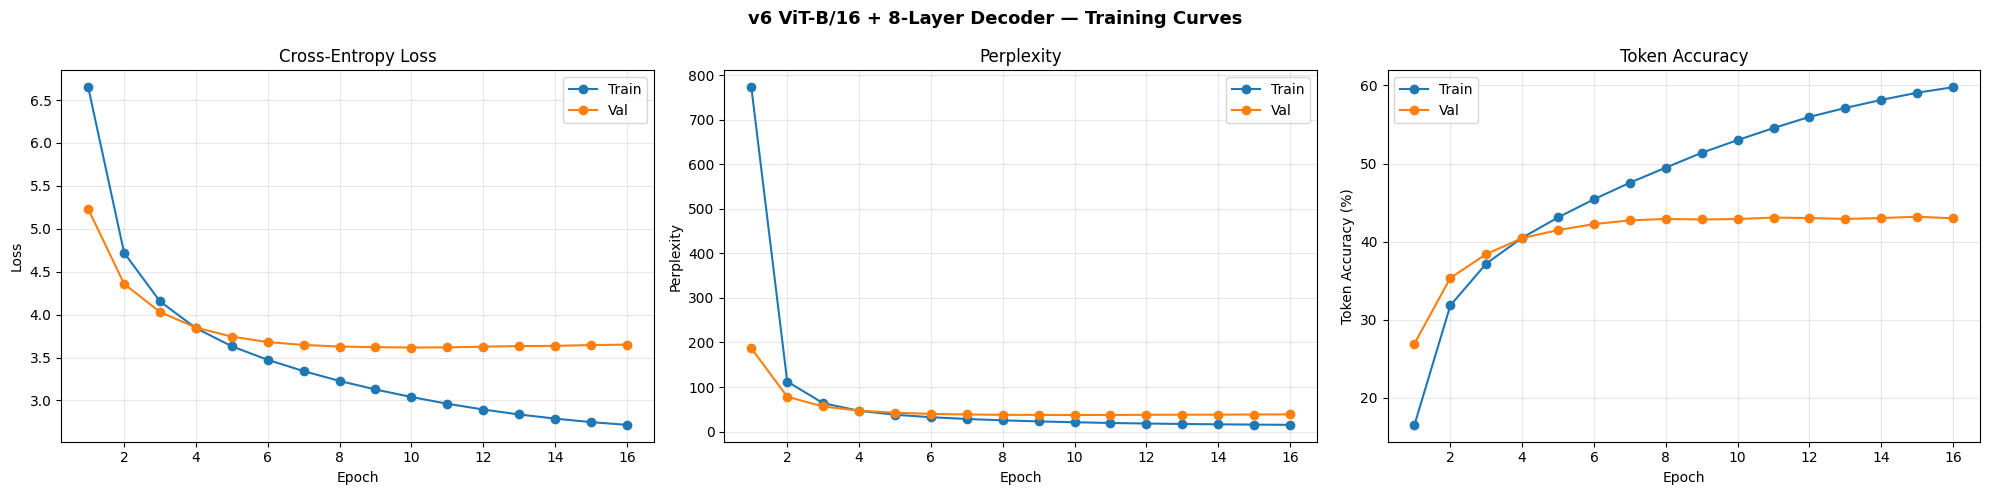

In [22]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val",   marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["train_ppl"], label="Train", marker="o")
axes[1].plot(epochs_ran, history["val_ppl"],   label="Val",   marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, [a * 100 for a in history["train_acc"]], label="Train", marker="o")
axes[2].plot(epochs_ran, [a * 100 for a in history["val_acc"]],   label="Val",   marker="o")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Token Accuracy (%)")
axes[2].set_title("Token Accuracy"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("v6 ViT-B/16 + 8-Layer Decoder — Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Inference — Beam Search

Load the best checkpoint and run **beam search (width=5)** for higher-quality captions.

In [23]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
ckpt = torch.load(SAVE_DIR / "best_model.pt", map_location=DEVICE)

hp = ckpt['hparams']
v  = ckpt['vocab']

best_model = ImageCaptioner(
    vocab_size = v['VOCAB_SIZE'],
    d_model    = hp['D_MODEL'],
    n_heads    = hp['N_HEADS'],
    n_layers   = hp['N_LAYERS'],
    d_ff       = hp['D_FF'],
    dropout    = hp['DROPOUT'],
    drop_path  = hp.get('DROP_PATH', 0.0),
    vit_dim    = hp.get('VIT_DIM', hp.get('CNN_DIM', 768)),
    n_spatial  = hp['N_SPATIAL'],
    max_seq    = hp['MAX_SEQ'],
).to(DEVICE)
best_model.load_state_dict(ckpt['model_state'])
best_model.eval()

_word2idx = v['word2idx']
_idx2word = {int(k): w for k, w in v['idx2word'].items()}
_PAD      = v['PAD_IDX']
_SOS      = v['SOS_IDX']
_EOS      = v['EOS_IDX']
_UNK      = v['UNK_IDX']

print(f"Loaded best model from epoch {ckpt['epoch']}  (val_loss={ckpt['val_loss']:.4f})")

Loaded best model from epoch 10  (val_loss=3.6172)


In [24]:
@torch.no_grad()
def generate_caption(image_path: str, model=best_model, beam_width: int = 5,
                     max_len: int = MAX_SEQ) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    Uses beam search with the frozen ViT-B/16 backbone + trained decoder.

    Args:
        image_path : path to a .jpg or .png image file
        model      : trained ImageCaptioner instance (default: best checkpoint)
        beam_width : number of beams for beam search (default: 5)
        max_len    : max caption length in tokens (default: MAX_SEQ)

    Returns:
        caption string (no special tokens)
    """
    model.eval()

    # ── Extract ViT patch features ─────────────────────────────────────────────
    img  = Image.open(image_path).convert("RGB")
    feat = img_transform(img).unsqueeze(0).to(DEVICE)   # (1, 3, 224, 224)
    with torch.no_grad():
        out     = backbone(feat)                         # (1, 197, 768)
        spatial = out[:, 1:, :]                          # drop CLS → (1, 196, 768)

    # ── Encode image once ──────────────────────────────────────────────────────
    memory = model.encode_image(spatial)                 # (1, 196, d_model)

    # ── Beam search ───────────────────────────────────────────────────────────
    beams    = [(0.0, [_SOS])]
    complete = []

    for _ in range(max_len):
        if not beams:
            break
        new_beams = []
        for score, tokens in beams:
            if tokens[-1] == _EOS:
                complete.append((score, tokens))
                continue

            t        = len(tokens)
            tgt_ids  = torch.tensor([tokens], dtype=torch.long, device=DEVICE)
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(t, device=DEVICE)
            logits   = model.decode(tgt_ids, memory.expand(1, -1, -1), tgt_mask=tgt_mask)
            log_prob = F.log_softmax(logits[0, -1], dim=-1)

            topk_lp, topk_idx = log_prob.topk(beam_width)
            for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                new_beams.append((score + lp, tokens + [idx]))

        # Length penalty alpha=0.75 to avoid penalising longer descriptive captions
        new_beams.sort(key=lambda x: x[0] / (len(x[1]) ** 0.75), reverse=True)
        beams     = [b for b in new_beams if b[1][-1] != _EOS][:beam_width]
        complete += [b for b in new_beams if b[1][-1] == _EOS]

    if not complete:
        complete = beams if beams else [(0.0, [_SOS, _EOS])]

    best_tokens = max(complete, key=lambda x: x[0] / (len(x[1]) ** 0.75))[1]
    words = []
    for i in best_tokens[1:]:   # skip SOS
        if i == _EOS:
            break
        words.append(_idx2word.get(i, '<unk>'))
    return " ".join(words)

## 12. Caption Preview

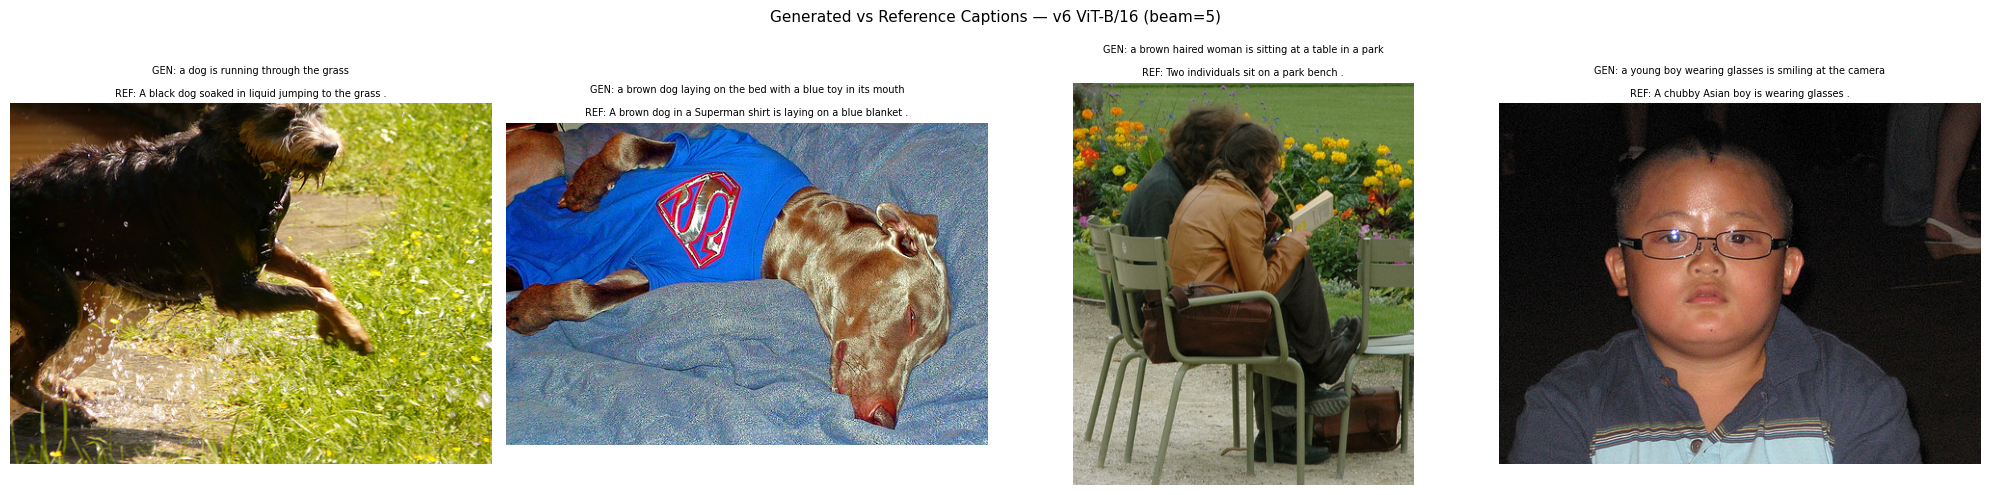

In [25]:
sample_rows = val_df.drop_duplicates('image').sample(4, random_state=SEED)
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = str(IMAGES_DIR / row['image'])
    caption  = generate_caption(img_path)
    ref_caps = val_df[val_df['image'] == row['image']]['caption'].tolist()

    ax.imshow(Image.open(img_path))
    ax.set_title(f"GEN: {caption}\n\nREF: {ref_caps[0]}", fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Generated vs Reference Captions — v6 ViT-B/16 (beam=5)', fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'caption_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. BLEU-4 Evaluation

Standard Flickr8k evaluation: each generated caption scored against all 5 reference captions.
Corpus BLEU-4 with method1 smoothing.

In [26]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

best_model.eval()
val_images = val_df['image'].unique().tolist()

all_references = []
all_hypotheses = []

print(f"Evaluating BLEU-4 on {len(val_images)} validation images...")

for i, img_name in enumerate(val_images):
    img_path = str(IMAGES_DIR / img_name)
    caption  = generate_caption(img_path)

    refs       = val_df[val_df['image'] == img_name]['caption'].tolist()
    ref_tokens = [r.lower().split() for r in refs]
    hyp_tokens = caption.lower().split()

    all_references.append(ref_tokens)
    all_hypotheses.append(hyp_tokens)

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(val_images)} done...")

smoother = SmoothingFunction().method1
bleu4 = corpus_bleu(all_references, all_hypotheses,
                    weights=(0.25, 0.25, 0.25, 0.25),
                    smoothing_function=smoother)
bleu1 = corpus_bleu(all_references, all_hypotheses, weights=(1,0,0,0),   smoothing_function=smoother)
bleu2 = corpus_bleu(all_references, all_hypotheses, weights=(.5,.5,0,0), smoothing_function=smoother)
bleu3 = corpus_bleu(all_references, all_hypotheses, weights=(.33,.33,.33,0), smoothing_function=smoother)

print(f"\nBLEU-1 : {bleu1*100:.2f}")
print(f"BLEU-2 : {bleu2*100:.2f}")
print(f"BLEU-3 : {bleu3*100:.2f}")
print(f"BLEU-4 : {bleu4*100:.2f}  ← primary metric")

Evaluating BLEU-4 on 810 validation images...
  100/810 done...
  200/810 done...
  300/810 done...
  400/810 done...
  500/810 done...
  600/810 done...
  700/810 done...
  800/810 done...

BLEU-1 : 66.24
BLEU-2 : 49.14
BLEU-3 : 35.85
BLEU-4 : 25.32  ← primary metric


## 14. Save Artifacts

In [27]:
with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)

print("Artifacts in:", SAVE_DIR)
print("  best_model.pt          — full checkpoint (model weights + vocab + hparams)")
print("  feat_cache_vit/        — pre-extracted ViT-B/16 patch features")
print("  training_curves.png    — loss, perplexity, accuracy plots")
print("  caption_examples.png   — sample generated captions")
print("  training_history.json  — per-epoch metrics")

Artifacts in: /kaggle/working
  best_model.pt          — full checkpoint (model weights + vocab + hparams)
  feat_cache_vit/        — pre-extracted ViT-B/16 patch features
  training_curves.png    — loss, perplexity, accuracy plots
  caption_examples.png   — sample generated captions
  training_history.json  — per-epoch metrics
